## K means clustering

MNIST bestaat uit plaatjes van cijfers (0 t/m 9).
Elk plaatje is een lijst van 784 pixelwaardes.
Om data te comprimeren willen we K means clustering toepassen om prototypes te maken.

### Opdracht 1

Wat stelt één prototype voor?



Waarom is dit geheugenbesparend?

Schrijf een functie **load_mnist** die:

- De MNIST-data laadt

- De pixelwaarden (eventueel) schaalt naar 0–1

- Er voor zorgt dat je labels ("5", "0" etc) omzet naar gehele getallen

<br>

#### Antwoorden
**Wat stelt één prototype voor?:** <br>
In K means clustering is een prototype het gemiddelde van een cluster datapunten. Dit centrum wordt **centroid** genoemd.

Bij MNIST afbeeldingen is elk datapunt een afbeelding van 28 x 28 pixels (vector lengte van 784). Een prototype heeft ook een vector lengte van 784. Deze vector, die van het prototype, is het gemiddelde beeld van alle afbeeldingen die in dat cluster vallen.

Bij MNIST bestaat dat cluster uit vergelijkbare afbeeldingen. Omdat K means unsupervised is worden de afbeeldingen vergeleken op basis van pixelwaarden. Cijfers die dus hetzelfde zijn komen bij elkaar in het cluster terrecht omdat ze overeenkomen in pixelwaarden. Het prototype is vervolgens het gemiddelde van het gevormde cluster.

<br>

**Waarom is dit geheugenbesparend?:** <br>
Zonder compressie sla je alle 60.000 afbeeldingen op, wat veel geheugen kost:
```
60.000 afbeeldingen
1 afbeelding = 784 pixelwaarden

60.000 x 784 = 47.040.000 getallen (pixelwaarden)
```

Wanneer je K means compressie toepast, sla je de K prototypes (centroids) op. Daarnaast sla je voor elk datapunt (afbeelding) een cluster index op die aangeeft bij welk prototype het hoort.

In K means kan je K zelf bepalen. K is het aantal clusters en dus ook het aantal prototypes.

Dus in plaats van alle afbeeldingen op te slaan bewaar je bijvoorbeeld (K = 100):
```
100 x 784 = 78.400 getallen (pixelwaarden)
+
Per afbeelding een cluster index = 60.000 getallen

Totaal:
60.000 + 78.400 = 138.400 getallen
```

Dat is veel minder dan wanneer je geen compressie toepast. Na compressie wordt nog maar 0.29% van de oorspronkelijke hoeveelheid data opgeslagen. De opslag is dus met ongeveer 99.71% verminderd.
```
(138.400 / 47.040.00) x 100 = 0.29%
```

Normaal sla je alle afbeeldingen volledig op, maar met K means sla je slechts op, op welk prototype de afbeelding het meest lijkt. De details van de afbeeldingen gooi je weg en je bewaart alleen een paar gemiddelde afbeeldingen (prototypes) en de verwijzing ernaar (index).



In [3]:
import numpy as np
from keras.datasets import mnist

def load_mnist(scale=True):
    (x_train, y_train), (x_test, y_test) = mnist.load_data()

    x_train = x_train.reshape(-1, 784)
    x_test = x_test.reshape(-1, 784)

    if scale:
        x_train = x_train.astype(np.float32) / 255.0
        x_test = x_test.astype(np.float32) / 255.0

    y_train = y_train.astype(int)
    y_test = y_test.astype(int)

    return x_train, y_train, x_test, y_test


### Stap 2: Prototypes maken

We maken per cijfer een aantal prototypes (gemiddelde plaatjes).

Schrijf een functie **make_prototype** die:

- Voor elk cijfer (0–9) de bijbehorende trainingsbeelden selecteert

- Met K-means k clusters maakt

- Alle cluster-centers opslaat als prototypes

- Per prototype het juiste cijfer onthoudt

- Alle prototypes en bijbehorende labels in een datastructuur returnt


Hint:

- Gebruik een for-loop over de cijfer waardes (0 - 9)

- maak van elk van de waardes een lijstje van de afbeeldingen die erij horen

- Gebruik KMeans uit sklearn.cluster on van dit lijstje een prototype te maken


    **km = KMeans(n_clusters=k)**
    
    vindt K groepen in de data

    **km.fit(X_digit)**

    je kunt de cluster centers ( prototypes) achterhalen met:

    **km.cluster_centers_**


Bedenk goed dat je functie terug moet geven: prototypes en labels. Denk na over welke datastructuur je hiervoor wilt gebruiken.



In [ ]:
from sklearn.cluster import KMeans

def make_prototype(x_train, y_train, k=10):
    prototypes_dict = {}

    for digit in range(10):
        x_digit = x_train[y_train == digit]

        km = KMeans(n_clusters=k)
        km.fit(x_digit)

        prototypes_dict[digit] = km.cluster_centers_

    return prototypes_dict


Maak nu een stukje code waarmee je de bovenstaande functies aanroept en een (of meer) van de prototypes laat zien.

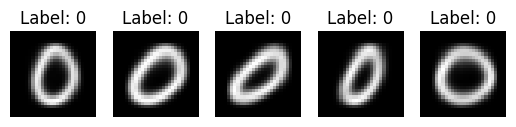

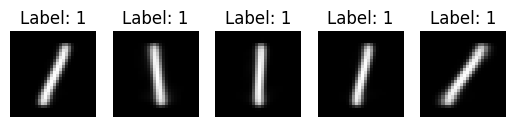

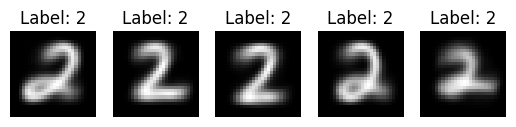

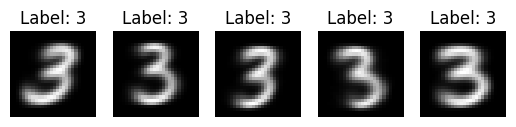

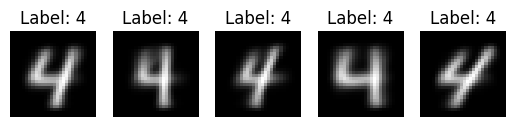

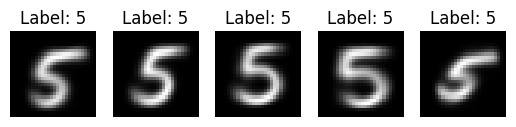

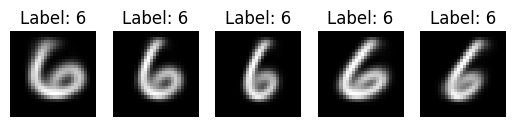

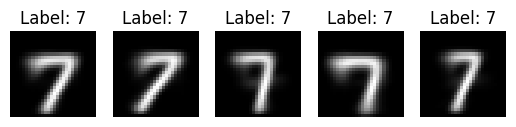

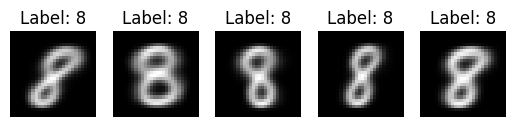

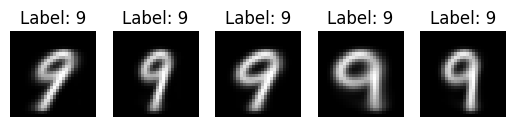

In [5]:
import matplotlib.pyplot as plt

x_train, y_train, x_test, y_test = load_mnist()
prototypes = make_prototype(x_train, y_train, k=5)

for digit, prototype in prototypes.items():
    fig, axes = plt.subplots(1, 5)

    for ax, proto in zip(axes, prototype):
        ax.imshow(proto.reshape(28, 28), cmap='gray')
        ax.set_title(f"Label: {digit}")
        ax.axis('off')

    plt.show()


### Stap 3 – Cijfers voorspellen

Stel we willen het cijfer voosrpellen foor te kijken naar de afstand tot een prototype.
Een onbekend plaatje wordt dus vergeleken met alle prototypes.

Om te beginnen moeten we een functie hebben die de afstanden tussen 2 afbeeldingen (of een lijst van pixels) berekent.

Noem de functie **get_distance(image1, image2)**. deze geeft een getal terug die de som is van alle pixel verschillen.




Schrijf een functie **predict** die:

- Voor elk testplaatje de afstand tot alle prototypes berekent

- Het prototype kiest dat het meest lijkt

- Het bijbehorende cijfer - de label van de beste prototype teruggeeft

Wat betekent “afstand” hier?

    Afstand staat voor het verschil tussen de pixelwaarden. De dichter bij de afstand, hoe meer de pixelwaarden overeenkomen en er een schatting gedaan kan worden.

Waarom gebruiken we de kleinste afstand?

    Omdat deze dan het meeste lijkt op de digit die we willen voorspellen.

In [ ]:
def predict(image, prototypes_dict):
    min_distance = float('inf')
    predicted_label = None

    for digit, prototypes in prototypes_dict.items():
        for proto in prototypes:
            # https://www.geeksforgeeks.org/python/calculate-the-euclidean-distance-using-numpy/
            distance = np.linalg.norm(image - proto)

            if distance < min_distance:
                min_distance = distance
                predicted_label = digit

    return predicted_label

test_image = x_test[0]
predicted_label = predict(test_image, prototypes)
print(f"Predicted label: {predicted_label}, True label: {y_test[0]}")


Predicted label: 7, True label: 7


Probeer nu een random afbeelding te voorspellen aan de hand van je **predict** functie.

### Stap 4 – Experimenteren

Schrijf code die:

- De data splitst in train en test

- Prototypes maakt (aan de hand van je eerder gemaakte functie)

- Voorspellingen doet (predict functie aanroept)

- De accuracy berekent

- Het geheugengebruik van de prototypes print

Hint:

- Accuracy = aantal juiste voorspellingen / totaal

        Tip: gebruik **accuracy = np.mean(y_pred == y_test)**

- Geheugen = array.nbytes

Test met:

k = 1, 3, 5, 10 of iets anders...


Wat gebeurt er met de accuracy als k groter wordt?

Wat gebeurt er met het geheugen?

Probeer een optimale setting te vinden en bereid hier een presentatie over.

k: 1, Memory Usage: 31360 bytes (30.62 KB), Success rate: 0.8203
k: 3, Memory Usage: 94080 bytes (91.88 KB), Success rate: 0.8816
k: 5, Memory Usage: 156800 bytes (153.12 KB), Success rate: 0.9024
k: 10, Memory Usage: 313600 bytes (306.25 KB), Success rate: 0.9225
k: 15, Memory Usage: 470400 bytes (459.38 KB), Success rate: 0.9325
k: 20, Memory Usage: 627200 bytes (612.50 KB), Success rate: 0.9358
k: 25, Memory Usage: 784000 bytes (765.62 KB), Success rate: 0.94
k: 30, Memory Usage: 940800 bytes (918.75 KB), Success rate: 0.946
k: 35, Memory Usage: 1097600 bytes (1071.88 KB), Success rate: 0.9479
k: 40, Memory Usage: 1254400 bytes (1225.00 KB), Success rate: 0.9494
k: 45, Memory Usage: 1411200 bytes (1378.12 KB), Success rate: 0.9509
k: 50, Memory Usage: 1568000 bytes (1531.25 KB), Success rate: 0.9534


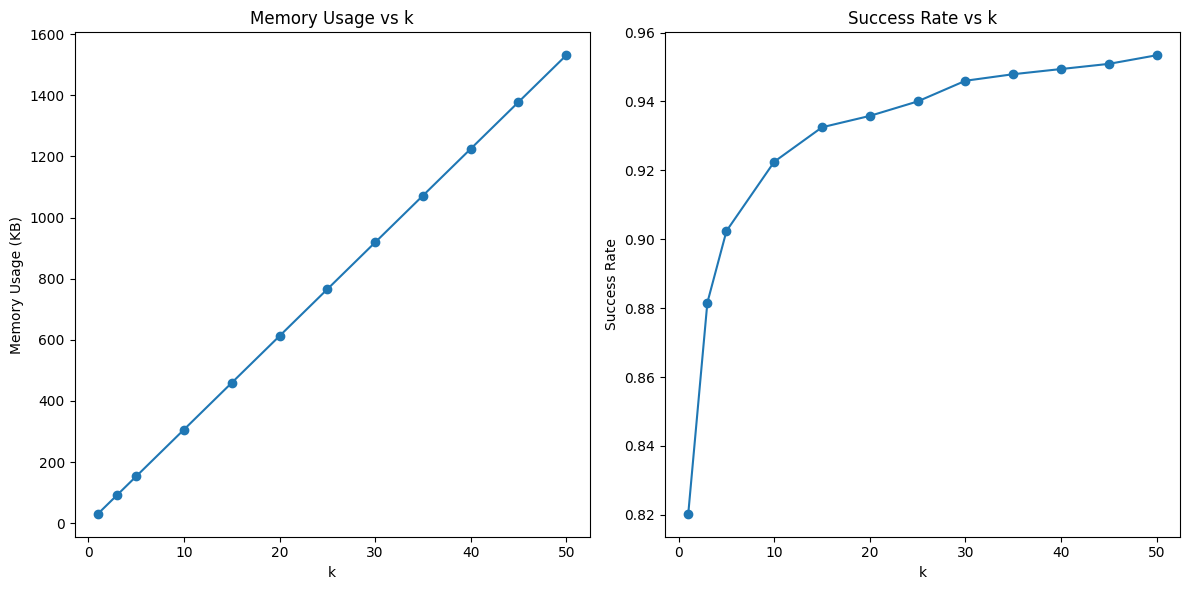

: 

In [ ]:
k_values = [1, 3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

graph_data = []

for k in k_values:
    prototypes = make_prototype(x_train, y_train, k)

    y_pred = [predict(image, prototypes) for image in x_test]

    total_memory_usage = sum(prototypes[digit].nbytes for digit in prototypes)
    
    print(f"k: {k}, Memory Usage: {total_memory_usage} bytes ({total_memory_usage / 1024 :.2f} KB), Success rate: {np.mean(y_pred == y_test)}")
    graph_data.append((k, total_memory_usage / 1024, np.mean(y_pred == y_test)))

k_values, memory_usages, success_rates = zip(*graph_data)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(k_values, memory_usages, marker='o')
plt.title('Memory Usage vs k')
plt.xlabel('k')
plt.ylabel('Memory Usage (KB)')
plt.subplot(1, 2, 2)
plt.plot(k_values, success_rates, marker='o')
plt.title('Success Rate vs k')
plt.xlabel('k')
plt.ylabel('Success Rate')
plt.tight_layout()
plt.show()

